<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#2dd4bf 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 156 &middot; Tools &amp; Workflow &middot; Notebook 5 of 5</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Tracking Experiments, End to End</div>
  <div style="font-size:15px;color:#ccfbf1;max-width:760px;line-height:1.6">The payoff of everything so far: an experiment is reproducible only when its code, data, seed, and environment are all recorded. A run log captures them per experiment, so you can prove which results repeat and spot the one that does not.</div>
</div>

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
TL, RD = "#0f766e", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "reproducibility-and-version-control--experiment-log.xlsx"
try: runs = pd.read_excel("../../data/" + fn, sheet_name="runs")
except FileNotFoundError: runs = pd.read_excel(BASE + fn, sheet_name="runs")
print(runs.shape); runs.head()

(20, 10)


,run_id,run_date,git_commit,seed,data_hash,python_version,sklearn_version,model,accuracy,note
0,1,2024-03-01,a1f3c9,42.0,e3b0c4,3.11.5,1.3.0,RandomForest,0.8793,NaN
1,2,2024-03-02,a1f3c9,42.0,e3b0c4,3.11.5,1.3.0,RandomForest,0.8793,NaN
2,3,2024-03-03,a1f3c9,7.0,e3b0c4,3.11.5,1.3.0,RandomForest,0.8791,NaN
3,4,2024-03-04,7b2e10,42.0,e3b0c4,3.11.5,1.3.0,RandomForest,0.8850,NaN
4,5,2024-03-05,7b2e10,7.0,e3b0c4,3.11.5,1.3.0,RandomForest,0.8380,NaN


## DEMO 1 &middot; Read the run log
Each row is one model run, tagged with the git commit (code), the data hash (inputs), the seed, the environment versions, and the accuracy it produced. This is exactly what a tool like MLflow records automatically.

In [2]:
print(runs[["run_id","git_commit","data_hash","seed","sklearn_version","accuracy","note"]].to_string(index=False))

 run_id git_commit data_hash  seed sklearn_version  accuracy        note
      1     a1f3c9    e3b0c4  42.0           1.3.0    0.8793         NaN
      2     a1f3c9    e3b0c4  42.0           1.3.0    0.8793         NaN
      3     a1f3c9    e3b0c4   7.0           1.3.0    0.8791         NaN
      4     7b2e10    e3b0c4  42.0           1.3.0    0.8850         NaN
      5     7b2e10    e3b0c4   7.0           1.3.0    0.8380         NaN
      6     c4d881    9f86d0  42.0           1.3.2    0.8090         NaN
      7     c4d881    9f86d0  42.0           1.3.2    0.8090         NaN
      8     c4d881    9f86d0   7.0           1.3.2    0.8433         NaN
      9     9e0a55    9f86d0  42.0           1.4.0    0.8489         NaN
     10     9e0a55    9f86d0  42.0           1.4.0    0.8489         NaN
     11     9e0a55    9f86d0   7.0           1.4.0    0.8648         NaN
     12     2f6b7c    9f86d0  42.0           1.4.0    0.8537         NaN
     13     2f6b7c    9f86d0   7.0           1.4.0 

## DEMO 2 &middot; Which runs are truly reproducible?
A run is reproducible when another run shares its code, data, and seed. Group by those three and, within each group, the accuracy should be identical. If it is, the group reproduces; if not, something unrecorded is leaking in.

In [3]:
seeded = runs.dropna(subset=["seed"])
grp = seeded.groupby(["git_commit","data_hash","seed"]).accuracy.agg(runs="count", distinct_scores="nunique")
print(grp.to_string())
print("\nevery group has exactly one distinct score:", (grp.distinct_scores == 1).all())
print("so identical (code, data, seed) always reproduces the identical result.")

                           runs  distinct_scores
git_commit data_hash seed                       
2f6b7c     9f86d0    7.0      1                1
                     42.0     1                1
55aa12     1a2b3c    7.0      1                1
                     42.0     2                1
7b2e10     e3b0c4    7.0      1                1
                     42.0     1                1
9e0a55     9f86d0    7.0      1                1
                     42.0     2                1
a1f3c9     e3b0c4    7.0      1                1
                     42.0     2                1
c4d881     9f86d0    7.0      1                1
                     42.0     2                1
d3c0e9     1a2b3c    7.0      1                1
                     42.0     2                1

every group has exactly one distinct score: True
so identical (code, data, seed) always reproduces the identical result.


## DEMO 3 &middot; Find the non-reproducible run
One run set no seed. Otherwise similar runs then disagree, the classic silent bug. The log makes it findable in one line, where without it you would chase a ghost for hours.

In [4]:
culprit = runs[runs.seed.isna()]
print("runs with no seed recorded:")
print(culprit[["run_id","git_commit","data_hash","seed","accuracy","note"]].to_string(index=False))
print("\nLesson: an unset seed is the most common reason 'the same analysis' gives two answers.")

runs with no seed recorded:
 run_id git_commit data_hash  seed  accuracy        note
     14     2f6b7c    9f86d0   NaN    0.8307 no seed set

Lesson: an unset seed is the most common reason 'the same analysis' gives two answers.


## DEMO 4 &middot; Visualize accuracy across runs
Plot every run's accuracy in order, and mark the unseeded run. A picture like this, kept over a project's life, is how teams see whether a change actually helped or just moved the noise.

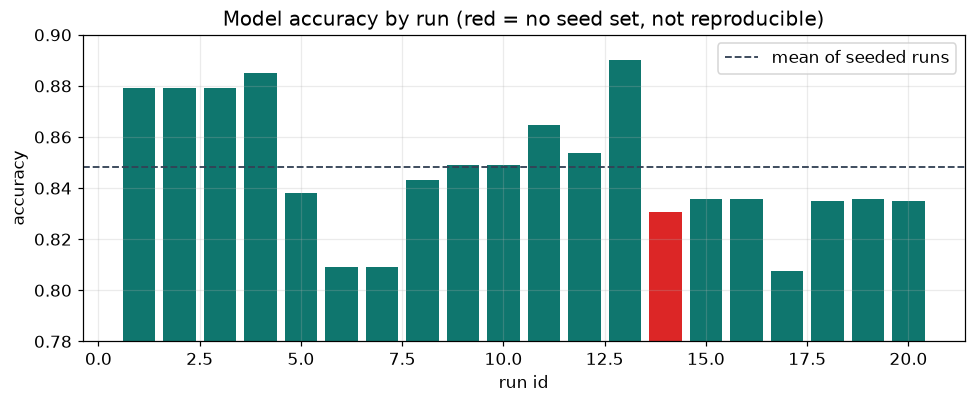

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [RD if pd.isna(s) else TL for s in runs.seed]
ax.bar(runs.run_id, runs.accuracy, color=colors)
ax.set_ylim(0.78, 0.90); ax.set_xlabel("run id"); ax.set_ylabel("accuracy")
ax.set_title("Model accuracy by run (red = no seed set, not reproducible)")
ax.axhline(runs[runs.seed.notna()].accuracy.mean(), color="#334155", ls="--", lw=1.2, label="mean of seeded runs")
ax.legend(); plt.tight_layout(); plt.show()

## DEMO 5 &middot; The reproducibility checklist
Bring it home: for any result, can you answer all four questions? The code version, the data version, the seed, and the environment. If yes, a stranger can reproduce it. If no, you cannot fully trust it yourself.

In [6]:
def reproducible(run):
    checks = {"code (git commit)": pd.notna(run.git_commit),
              "data (hash)":       pd.notna(run.data_hash),
              "seed":              pd.notna(run.seed),
              "environment":       pd.notna(run.sklearn_version)}
    return checks

for rid in [1, 14]:
    r = runs[runs.run_id == rid].iloc[0]
    checks = reproducible(r)
    print(f"run {rid}: " + ("REPRODUCIBLE" if all(checks.values()) else "NOT fully reproducible"))
    for k, v in checks.items(): print(f"    {'OK ' if v else 'MISSING'}  {k}")

run 1: REPRODUCIBLE
    OK   code (git commit)
    OK   data (hash)
    OK   seed
    OK   environment
run 14: NOT fully reproducible
    OK   code (git commit)
    OK   data (hash)
    MISSING  seed
    OK   environment


### Wrap-up
Reproducibility is not one habit but four working together: version the **code** (git), fingerprint the **data** (a hash), fix the **seed**, and pin the **environment**. A run log that records all four turns 'I think this is right' into 'anyone can check this is right', which is the whole point. That is where the toolkit of this book, from a first mean to a deployed model, finally becomes trustworthy.